In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from keras.datasets import mnist


In [8]:
tf.keras.datasets.fashion_mnist.load_data()
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()



In [11]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

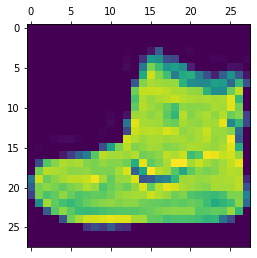

In [14]:
plt.matshow(x_train[0])

In [17]:
y_train[0]

9

In [20]:
x_train.shape

(60000, 28, 28)

In [23]:
#converting a 2d array to 1d
x_train_fl = x_train.reshape(len(x_train),28*28)
x_test_fl = x_test.reshape(len(x_test),28*28)

In [26]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,),
    activation = 'sigmoid')
])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_fl,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 11s 5ms/step - loss: 17.1245 - accuracy: 0.7476
Epoch 2/5
1875/1875 [==============================] - 11s 6ms/step - loss: 12.0835 - accuracy: 0.7864
Epoch 3/5
1875/1875 [==============================] - 12s 6ms/step - loss: 11.5762 - accuracy: 0.7943
Epoch 4/5
1875/1875 [==============================] - 12s 6ms/step - loss: 10.7952 - accuracy: 0.8005
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 10.8063 - accuracy: 0.8015


In [29]:
model.evaluate(x_test_fl,y_test)

313/313 [==============================] - 1s 5ms/step - loss: 16.7965 - accuracy: 0.7255


[16.79645538330078, 0.7254999876022339]

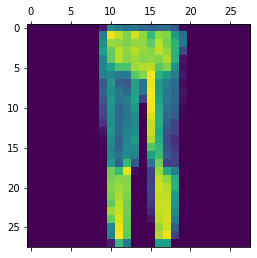

In [32]:
 plt.matshow(x_test[3])

In [35]:
y_predicted = model.predict(x_test_fl)
y_predicted[3]

array([1., 1., 1., 1., 1., 0., 1., 0., 0., 0.], dtype=float32)

In [38]:
np.argmax(y_predicted[3])

0

In [41]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [44]:
#confusion matrix
cm = tf.math.confusion_matrix(labels= y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[995,   0,   1,   0,   0,   0,   4,   0,   0,   0],
       [998,   1,   1,   0,   0,   0,   0,   0,   0,   0],
       [992,   2,   5,   0,   0,   0,   1,   0,   0,   0],
       [997,   2,   1,   0,   0,   0,   0,   0,   0,   0],
       [989,   2,   9,   0,   0,   0,   0,   0,   0,   0],
       [ 40,   9, 128, 243,  20, 559,   0,   1,   0,   0],
       [973,   3,  20,   0,   0,   0,   4,   0,   0,   0],
       [  2,   0,  15, 433,   4, 545,   0,   1,   0,   0],
       [504,  11, 223,  16,   0,  10, 139,   2,  94,   1],
       [ 52,   0,  24,  39,   0, 885,   0,   0,   0,   0]], dtype=int32)>

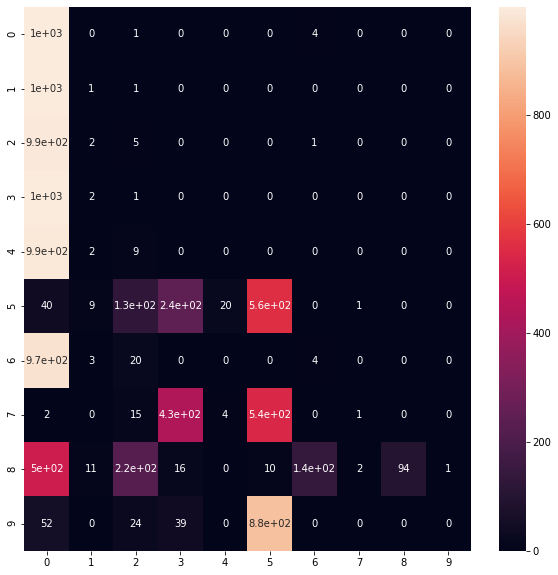

In [42]:
import seaborn as sn
plt.figure(figsize= (10,10))
sn.heatmap(cm,annot=True)
plt.show()

In [49]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,),activation = 'relu'),
    keras.layers.Dense(10,activation = 'sigmoid') 
])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_fl,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 13s 6ms/step - loss: 3.5012 - accuracy: 0.6846
Epoch 2/5
1875/1875 [==============================] - 11s 6ms/step - loss: 0.7043 - accuracy: 0.7511
Epoch 3/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.6252 - accuracy: 0.7762
Epoch 4/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.6093 - accuracy: 0.7853
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.5877 - accuracy: 0.7913


In [50]:
model.evaluate(x_test_fl,y_test)

313/313 [==============================] - 2s 5ms/step - loss: 0.6032 - accuracy: 0.7928


[0.6032174825668335, 0.7928000092506409]

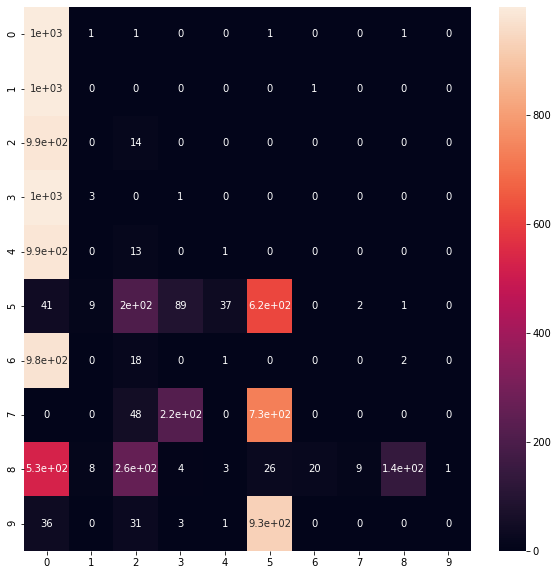

In [51]:

import seaborn as sn
plt.figure(figsize= (10,10))
sn.heatmap(cm,annot=True)
plt.show()

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28 ))
    keras.layers.Dense(100,activation = 'relu'),
    keras.layers.Dense(10,activation = 'sigmoid') 
])

model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train,y_train,epochs=5)

Activation function
loss and cost function

In [6]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]